# Gradient Boosting

In [23]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier,GradientBoostingRegressor
from sklearn.metrics import accuracy_score

In [10]:
df = load_breast_cancer()
X = df.data
y = df.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=1)

gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

y_pred = gb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9429824561403509


In [5]:
gb = GradientBoostingClassifier()
param_grid = {
    'n_estimators':[50,100,200],
    'learning_rate':[0.01,0.1,0.2],
    'max_depth': [3,5,7]
}
grid = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

# =========================
# BEST MODEL
# =========================

best_model = grid.best_estimator_

print("\nBest Parameters:")
print(grid.best_params_)

print("\nBest CV Accuracy:")
print(round(grid.best_score_ * 100, 2))


Best Parameters:
{'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200}

Best CV Accuracy:
95.9


In [11]:
# Problem 2: Titanic Survival Prediction
import seaborn as sns 
import numpy as np
import pandas as pd 

df = sns.load_dataset('titanic')

# impute missing values using knn imputers in age
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
df['age'] = imputer.fit_transform(df[['age']])

# impute embarked missing values using pandas
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])
# drop deck column
df.drop('deck', axis=1, inplace=True)

# df missing values
df.isnull().sum().sort_values(ascending=False)

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

In [12]:
# convert each category column to category
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
# add this as a new column in the dataframe
df[categorical_cols] = df[categorical_cols].astype('category')

from sklearn.preprocessing import LabelEncoder


for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

C:\Users\BAHU Computers\AppData\Local\Temp\ipykernel_7560\71400582.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns


In [13]:
X = df.drop(['survived','alive','alone'],axis=1)
y = df['survived']

# split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
gb.fit(X_train, y_train)

y_pred = gb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
gb.feature_importances_

Accuracy: 0.8379888268156425


array([0.11745624, 0.00553418, 0.07597516, 0.01181565, 0.00993319,
       0.21167202, 0.00435339, 0.06530778, 0.00130288, 0.48823409,
       0.00841543])

In [ ]:
gb = GradientBoostingClassifier()
param_grid = {
    'n_estimators':[50,100,200],
    'learning_rate':[0.01,0.1,0.2],
    'max_depth': [3,5,7]
}
grid = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

# =========================
# BEST MODEL
# =========================

best_model = grid.best_estimator_

print("\nBest Parameters:")
print(grid.best_params_)

print("\nBest CV Accuracy:")
print(round(grid.best_score_ * 100, 2))


Best Parameters:
{'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200}

Best CV Accuracy:
82.86


In [20]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing(as_frame=True)

df = housing.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [22]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [26]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

gb = GradientBoostingRegressor(n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42)
gb.fit(X_train, y_train)

y_pred = gb.predict(X_test)

r2 = r2_score(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)

print(r2)
print(mse)

0.7756446042829697
0.2939973248643864


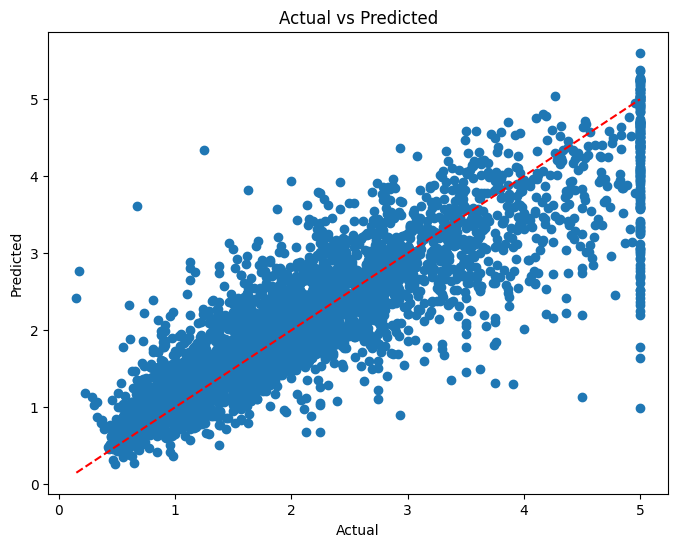

In [32]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.show()

In [33]:
params = {
    'n_estimators':[100,200],
    'learning_rate':[0.01,0.1],
    'max_depth':[3,5]
}
grid = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("\nBest Parameters:")
print(grid.best_params_)

print("\nBest CV Accuracy:")
print(round(grid.best_score_ * 100, 2))

c:\Users\BAHU Computers\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan]
  warnings.warn(



Best Parameters:
{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}

Best CV Accuracy:
nan


In [34]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_pred = best_model.predict(X_test)

print("R2 Score :", round(r2_score(y_test, y_pred), 4))
print("MAE      :", round(mean_absolute_error(y_test, y_pred), 4))
print("MSE      :", round(mean_squared_error(y_test, y_pred), 4))
print("RMSE     :", round(np.sqrt(mean_squared_error(y_test, y_pred)), 4))

R2 Score : 0.3442
MAE      : 0.7292
MSE      : 0.8594
RMSE     : 0.927
